<a href="https://colab.research.google.com/github/kimdonggyu2008/Personal_Study/blob/main/S4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from functools import partial
import jax
import jax.numpy as np
from flax import linen as nn
from jax.nn.initializers import lecun_normal, normal
from jax.numpy.linalg import eigh, inv, matrix_power
from jax.scipy.signal import convolve

In [2]:
if __name__=="__main__":
  rng=jax.random.PRNGKey(1)

In [3]:
rng

Array([0, 1], dtype=uint32)

In [4]:
def random_SSM(rng, N):
    a_r, b_r, c_r = jax.random.split(rng, 3)
    A = jax.random.uniform(a_r, (N, N))
    B = jax.random.uniform(b_r, (N, 1))
    C = jax.random.uniform(c_r, (1, N))
    return A, B, C

In [5]:
A,B,C=random_SSM(rng,3)
print(A,B,C)

[[0.70261526 0.23483467 0.81786454]
 [0.17094111 0.02634776 0.92260945]
 [0.6944734  0.39161062 0.7033144 ]] [[0.40364635]
 [0.548895  ]
 [0.2226392 ]] [[0.5577841  0.22405517 0.7470813 ]]


In [6]:
def discretize(A, B, C, step):
    I = np.eye(A.shape[0])
    BL = inv(I - (step / 2.0) * A)
    Ab = BL @ (I + (step / 2.0) * A)
    Bb = (BL * step) @ B
    return Ab, Bb, C

In [7]:
Ab, Bb, C=discretize(A,B,C,0.1)
print(Ab,Bb,C)

[[1.0762633  0.02616097 0.08925048]
 [0.02124082 1.004785   0.09675266]
 [0.07515424 0.041627   1.0780704 ]] [[0.04361532]
 [0.05652656]
 [0.02579223]] [[0.5577841  0.22405517 0.7470813 ]]


In [8]:
def scan_SSM(Ab, Bb, Cb, u, x0):
    def step(x_k_1, u_k):
        print(Ab.shape)
        print(x_k_1.shape)
        print(Bb.shape)
        print(u_k.shape)

        x_k = Ab @ x_k_1 + Bb @ u_k
        y_k = Cb @ x_k
        return x_k, y_k

    return jax.lax.scan(step, x0, u)

In [9]:
def run_SSM(A,B,C,u):
  L=u.shape[0]
  N=A.shape[0]
  Ab,Bb,C=discretize(A,B,C,1/L)

  return scan_SSM(Ab,Bb,C,u[:,np.newaxis],np.zeros((N,)))[1]

In [10]:
def example_mass(k,b,m):
  A=np.array([[0,1],[-k/m, -b/m]])
  B=np.array([[0],[1.0/m]])
  C=np.array([[1.0,0]])
  return A,B,C

In [11]:
def example_force(t):
  x=np.sin(10*t)
  return x*(x>0.5)

In [12]:
!pip install celluloid

In [13]:
def example_ssm():
  ssm=example_mass(k=40,b=5,m=1)
  L=100
  step=1.0/L
  ks=np.arange(L)
  u=example_force(ks*step)

  y=run_SSM(*ssm,u)


  # Plotting ---
  import matplotlib.pyplot as plt
  import seaborn
  from celluloid import Camera

  seaborn.set_context("paper")
  fig, (ax1, ax2, ax3) = plt.subplots(3)
  camera = Camera(fig)
  ax1.set_title("Force $u_k$")
  ax2.set_title("Position $y_k$")
  ax3.set_title("Object")
  ax1.set_xticks([], [])
  ax2.set_xticks([], [])

  # Animate plot over time
  for k in range(0, L, 2):
      ax1.plot(ks[:k], u[:k], color="red")
      ax2.plot(ks[:k], y[:k], color="blue")
      ax3.boxplot(
          [[y[k, 0] - 0.04, y[k, 0], y[k, 0] + 0.04]],
          showcaps=False,
          whis=False,
          vert=False,
          widths=10,
      )
      camera.snap()
  anim = camera.animate()
  anim.save("/content/sample_data/line.gif", dpi=150, writer="imagemagick")

In [14]:
if False:
    example_ssm()

In [15]:
def K_conv(Ab,Bb,Cb,L):
  return np.array(
      [(Cb@matrix_power(Ab,i)@Bb).reshape() for i in range(L)]
  )

In [16]:
# def K_conv(Ab, Bb, Cb, L):
#     kernel = []
#     for i in range(L):
#         middle = Cb @ matrix_power(Ab, i) @ Bb
#         kernel.append(middle.reshape(-1))  # reshape for flat array if needed
#     return np.array(kernel)


In [17]:
def causal_convolution(u,K,nofft=False): #1d 인과적 컨볼루션
  if nofft:
    return convolve(u,K,mode="full")[:u.shape[0]]
  else:
    assert K.shape[0]==u.shape[0] #동일 길이
    ud=np.fft.rfft(np.pad(u,(0,K.shape[0])))
    Kd=np.fft.rfft(np.pad(K,(0,u.shape[0])))
    out=ud*Kd
    return np.fft.irfft(out)[:u.shape[0]]

In [18]:
def test_cnn_is_rnn(N=4, L=16, step=1.0 / 16):
    ssm = random_SSM(rng, N)
    u = jax.random.uniform(rng, (L,))
    jax.random.split(rng, 3)
    # RNN
    rec = run_SSM(*ssm, u)

    # CNN
    ssmb = discretize(*ssm, step=step)
    conv = causal_convolution(u, K_conv(*ssmb, L))

    # Check
    assert np.allclose(rec.ravel(), conv.ravel())

In [19]:
result=test_cnn_is_rnn(4,16,1.0/16)

(4, 4)
(4,)
(4, 1)
(1,)


In [20]:
def log_step_initializer(dt_min=0.001,dt_max=0.1):
  def init(key,shape): #초기화 생성
    return jax.random.uniform(key,shape)*(
        np.log(dt_max)-np.log(dt_min)
    )+np.log(dt_min)

In [21]:
class SSMLayer(nn.Module):
  N:int
  l_max:int
  decode:bool=False

  def setup(self):
    self.A=self.params("A",lecun_normal(),(self.N,self.N)) #(N,N)
    self.B=self.params("B",lecun_normal(),(self.N,1)) #(N,1)
    self.C=self.params("C",lecun_normal(),(1,self.N)) #(1,N)
    self.D=self.params("D",nn.initializers.ones,(1,)) #(1,)

    self.log_step=self.param("log_step",log_step_initializer(),(1,)) #(1,)

    step=np.exp(self.log_step) #(1,)
    self.ssm=discretize(self.A,self.B,self.C,step=step) #(N,N),(N,1)(1,N)
    self.K=K_conv(*self.ssm,self.l_max) # (1_MAX,)

    self.x_k_1=self.variable("cache","cache_x_k",np.zeros,(self.N,)) #(N,)


  def __call__(self,u): # U=(N,)
    if not self.decode:
      return causal_convolution(u,self.K)+self.D*u

    else:
      x_k,y_s=scan_SSM(*self.ssm,u[:,np.newaxis],self.x_k_1.value)
      if self.is_mutable_collection("cache"):
        self.x_k_1.value=x_k
      return y_s.reshape(-1).real+self.D*u #(T,)

In [23]:
def cloneLayer(layer):
  return nn.vmap(
      layer,
      in_axes=1,
      out_axes=1,
      variable_axes={"params":1,"cache":1,"prime":1},
      split_rngs={"params":True},
  )

In [24]:
SSMLayer=cloneLayer(SSMLayer)

In [25]:
class SequenceBlock(nn.Module):
  layer_cls:nn.Module
  layer:dict
  dropout:float
  d_model:int
  prenorm:bool=True
  training:bool=True
  decode:bool=False


  def setup(self):
    self.seq=self.layer_cls(**self.layer,decode=self.decode)
    self.norm=nn.LayerNorm()
    self.out=nn.Dense(self.d_model)
    if self.glu:
      self.out2=nn.Dense(self.d_model)
    self.drop=nn.Dropout(
        self.dropout,
        broadcast_dims=[0],
        deterministic=not self.training,
    )

  def __call__(self,x):
    skip=x
    if self.prenorm:
      x=self.norm(x)
    x=self.seq(x)
    x=self.drop(nn.gelu(x))
    if self.glu:
      x=self.out(x)*jax.nn.sigmoid(self.out2(x))
    else:
      x=self.out(x)
    x=skip+self.drop(x)
    if not self.prenorm:
      x=self.norm(x)
    return x

In [26]:
class Embedding(nn.Embed):
  num_embeddings:int
  features: int

  @nn.compact
  def __call__(self,x):
    y=nn.Embed(self.num_embeddings,self.features)(x[...,0])
    return np.where(x>0,y,0.0)

In [27]:
class StackedModel(nn.Module):
  layers_cls:nn.Module
  layer:dict
  d_output:int
  d_model:int
  n_layers:int
  prenorm:bool=True
  dropout:float=0.0
  embedding:bool=False
  classification:bool=False
  training:bool=True
  decode:bool=False

  def setup(self):
    if self.embedding:
      self.encoder=Embedding(self.d_output,self.d_model)
    else:
      self.encoder=nn.Dense(self.d_model)
    self.decoder=nn.Dense(self.d_output)
    self.layers=[
        SequenceBlock(
            layer_cls=self.layers_cls,
            layer=self.layer,
            dropout=self.dropout,
            d_model=self.d_model,
            training=self.training,
            decode=self.decode,
        )
        for _ in range(self.n_layers)
    ]

  def __call__(self,x):
    if not self.classification:
      if not self.embedding:
        x=x/255.0
      if not self.decode:
        x=np.pad(x[:-1],[(1,0),(0,0)])
      x=self.encoder(x)
      for layer in self.layers:
        x=layer(x)
      if self.classification:
        x=np.mean(x,axis=0)
      x=self.decoder(x)
      return nn.log_softmax(x,axis=-1)


In [28]:
BatchStackedModel=nn.vmap(
    StackedModel,
    in_axes=0,
    out_axes=0,
    variable_axes={"params":None,"dropout":None,"cache":0,"prime":None},
    split_rngs={"params":False,"dropout":True},
)

# hippo

In [29]:
def make_HiPPO(N):
  P=np.sqrt(1+2*np.arange(N))
  A=P[:,np.newaxis]*P[np.newaxis,:]
  A=np.tril(A)-np.diag(np.arange(N))
  return -A

In [33]:
from mpl_toolkits.mplot3d import Axes3D  # 3D 플롯을 위해 필요
import matplotlib.pyplot as plt
import seaborn
import numpy as np
import numpy.polynomial.legendre

def example_legendre(N=8):
    x = (np.random.rand(N) - 0.5) * 2
    t = np.linspace(-1, 1, 100)
    f = numpy.polynomial.legendre.Legendre(x)(t)

    seaborn.set_context("talk")
    fig = plt.figure(figsize=(20, 10))
    ax = fig.add_subplot(111, projection="3d")  # <- 이 부분 수정

    ax.plot(
        np.linspace(-25, (N - 1) * 100 + 25, 100),
        [0] * 100,
        zs=-1,
        zdir="x",
        color="black",
    )
    ax.plot(t, f, zs=N * 100, zdir="y", c="r")
    for i in range(N):
        coef = [0] * N
        coef[N - i - 1] = 1
        ax.set_zlim(-4, 4)
        ax.set_yticks([])
        ax.set_zticks([])
        f = numpy.polynomial.legendre.Legendre(coef)(t)
        ax.bar(
            [100 * i],
            [x[i]],
            zs=-1,
            zdir="x",
            label="x%d" % i,
            color="brown",
            fill=False,
            width=50,
        )
        ax.plot(t, f, zs=100 * i, zdir="y", c="b", alpha=0.5)
    ax.view_init(elev=40.0, azim=-45)
    fig.savefig("/content/sample_data/leg.png")  # 로컬에 저장됨


#검정색 바는 hidden state

#빨강은 우리가 예측한 함수

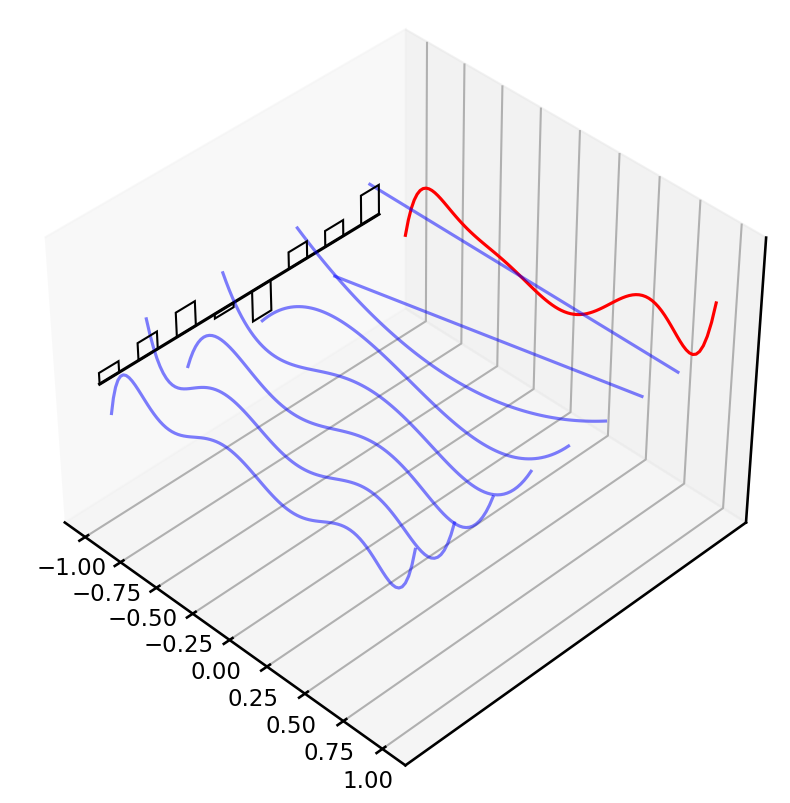

In [34]:
if True:
    example_legendre()

In [36]:
def K_gen_simple(Ab,Bb,Cb,L):
  K=K_conv(Ab,Bb,Cb,L)

  def gen(z):
    return np.sum(K*(z**np.arange(L)))

  return gen

In [37]:
def conv_from_gen(gen,L):
  Omega_L=np.exp((-2j*np.pi)*(np.arange(L)/L))
  atRoots=jax.vmap(gen)(Omega_L)
  out=np.fft.ifft(atRoots,L).reshape(L)
  return out.real

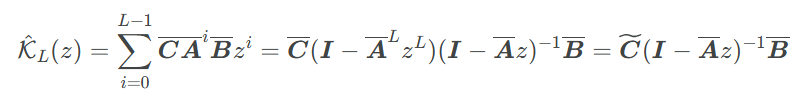

In [38]:
def K_gen_inverse(Ab,Bb,Cb,L):
  I=np.eye(Ab.shape[0]) #단위 행렬
  Ab_L=matrix_power(Ab,L) #행렬 a를 l번 곱한 결과(누적곱)
  Ct=Cb@(I-Ab_L) #각 누적곱과 Cb 곱함
  return lambda z: (Ct.conj()@inv(I-Ab*z)@Bb).reshape() #

In [39]:
def test_gen_inverse(L=16,N=4):
  ssm=random_SSM(rng,N)
  ssm=discretize(*ssm,1.0/L)
  b=K_conv(*ssm,L=L)

  a=conv_from_gen(K_gen_inverse(*ssm,L=L),L)
  assert np.allclose(a,b)

In [35]:
# import numpy as np
# from numpy.linalg import matrix_power

# # 상태 전이 행렬 A (간단한 예시)
# A = np.array([
#     [0.8, 0.1],
#     [0.0, 0.9]
# ])

# # L = 1부터 5까지 누적곱 계산
# for L in range(1, 6):
#     A_L = matrix_power(A, L)
#     print(f"A^{L} =\n{A_L}\n")

A^1 =
[[0.8 0.1]
 [0.  0.9]]

A^2 =
[[0.64 0.17]
 [0.   0.81]]

A^3 =
[[0.512 0.217]
 [0.    0.729]]

A^4 =
[[0.4096 0.2465]
 [0.     0.6561]]

A^5 =
[[0.32768 0.26281]
 [0.      0.59049]]



In [40]:
def cauchy_dot(v,omega,lambd):
  return (v/(omega-lambd)).sum()



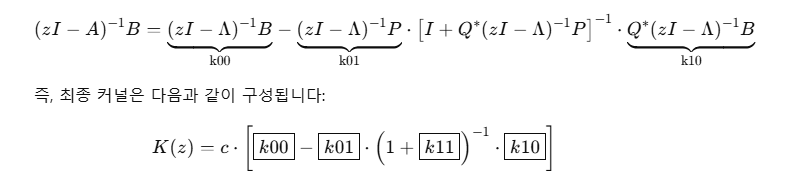



In [41]:
def K_gen_DPLR(Lambda,P,Q,B,C,step,unmat=False): #dplr 구조 상태공간 모델
  aterm=(C.conj(),Q.conj())
  bterm=(B,P)

  def gen(o):
    g=(2.0/step)*((1.0-o)/(1.0+o)) #bilinear transformer
    c=2.0/(1.0+o)

    def k(a):
      if unmat:
        return jax.remat(cauchy_dot)(a,g,Lambda) #cauchy dot
      else:
        return cauchy_dot(a,g,Lambda)

    k00=k(aterm[0]*bterm[0]) #cauchy kernel의 내적값들
    k01=k(aterm[0]*bterm[1])
    k10=k(aterm[1]*bterm[0])
    k11=k(aterm[1]*bterm[1])
    return c*(k00-k01*(1.0/(1.0+k11))*k10)
  return gen

In [42]:
def cauchy(v,omega,lambd):
  cauchy_dot=lambda _omega: (v/(_omega-lambd)).sum()
  return jax.vmap(cauchy_dot)(omega)

In [55]:
def kernel_DPLR(Lambda,P,Q,B,C,step,L):
  Omega_L=np.exp((-2j*np.pi)*(np.arange(L)/L))

  aterm=(C.conj(),Q.conj())
  bterm=(B,P)

  g = (2.0 / step) * ((1.0 - Omega_L) / (1.0 + Omega_L))
  c=2.0/(1.0+Omega_L)

  k00 = cauchy(aterm[0] * bterm[0], g, Lambda)
  k01 = cauchy(aterm[0] * bterm[1], g, Lambda)
  k10 = cauchy(aterm[1] * bterm[0], g, Lambda)
  k11 = cauchy(aterm[1] * bterm[1], g, Lambda)
  atRoots=c*(k00-k01*(1.0/(1.0+k11))*k10)
  out=np.fft.ifft(atRoots,L).reshape(L)
  return out.real


In [56]:
def random_DPLR(rng, N):
    l_r, p_r, q_r, b_r, c_r = jax.random.split(rng, 5)
    Lambda = jax.random.uniform(l_r, (N,))
    P = jax.random.uniform(p_r, (N,))
    Q = jax.random.uniform(q_r, (N,))
    B = jax.random.uniform(b_r, (N, 1))
    C = jax.random.uniform(c_r, (1, N))
    return Lambda, P, Q, B, C

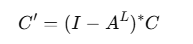

In [57]:
def test_gen_dplr(L=16,N=4):
  I=np.eye(4)

  Lambda,P,B,_=make_DPLR_HiPPO(N) #HIPPO 기반 연속 SSM
  A=np.diag(Lambda)-P[:,np.newaxis]@P[:,np.newaxis].conj().T
  _,_,C=random_SSM(rng.N)

  Ab,Bb,Cb=discretize(A,B,C,1.0/L)#이산화
  a=K_conv(Ab,Bb,Cb.conj(),L=L) #커널 생성

  C=(I-matrix_power(Ab,L)).conj().T@Cb.ravel() #flatten 진행
  b=kernel_DPLR(Lambda,P,P,B,C,step=1.0/L,L=L) #dplr 커널 생성
  assert np.allclose(a.real,b.real)

In [58]:
def discrete_DPLR(Lambda,P,Q,B,C,step,L):
  B=B[:,np.newaxis]
  Ct=C[np.newaxis,:]
  N=Lambda.shape[0]
  A=np.diag(Lambda)-P[:,np.newaxis]@Q[:,np.newaxis].conj().T
  I=np.eye(N)

  A0=(2.0/step)*I+A

  D=np.diag(1.0/((2.0/step)-Lambda))
  Qc=Q.conj().T.reshape(1,-1)
  P2=P.reshape(-1,1)
  A1=D-(D@P2*(1.0/(1+(Qc@D@P2)))@Qc@D)

  Ab=A1@A0
  Bb=2*A1@B

  Cb=Ct@inv(I-matrix_power(Ab,L)).conj()
  return Ab,Bb,Cb.conj()


In [59]:
def make_NPLR_HiPPO(N):
  nhippo=make_HiPPO(N)
  P=np.sqrt(np.arange(N)+0.5)
  B=np.sqrt(2*np.arange(N)+1.0)
  return nhippo,P,B

In [60]:
def make_DPLR_HiPPO(N):
  A,P,B=make_NPLR_HiPPO(N)
  S=A+P[:,np.newaxis]*P[np.newaxis,:]

  S_diag=np.diagonal(S)
  Lambda_real=np.mean(S_diag)*np.ones_like(S_diag)

  Lambda_imag,V=eigh(S* -1j)

  P=V.conj().T@P
  B=V.conj().T@B
  return Lambda_real+1j*Lambda_imag,P,B,V

In [61]:
def test_nplr(N=8):
  A2,P,B=make_NPLR_HiPPO(N)
  Lambda,Pc,Bc,V=make_DPLR_HiPPO(N)
  Vc=V.conj().T
  P=P[:,np.newaxis]
  Pc=Pc[:,np.newaxis]
  Lambda=np.diag(Lambda)

  A3=V@Lambda@Vc-(P@P.T)
  A4=V@(Lambda-Pc@Pc.conj().T)@Vc
  assert np.allclose(A2,A3,atol=1e-4,rtol=1e-4)
  assert np.allclose(A2,A4,atol=1e-4,rtol=1e-4)

In [62]:
def test_conversion(N=8,L=16):
  step=1.0/L
  Lambda,P,B,_=make_DPLR_HiPPO(N)
  C=normal(dtype=np.complex64)(rng,(N,))

  K = kernel_DPLR(Lambda, P, P, B, C, step, L)

  Ab,Bb,Cb=discrete_DPLR(Lambda,P,P,B,C,step,L)
  K2=K_conv(Ab,Bb,Cb,L=L)
  assert np.allclose(K.real,K2.real,atol=1e-5,rtol=1e-5)

  u=np.arange(L)*1.0
  y1=causal_convolution(u,K.real)

  _,y2=scan_SSM(
      Ab,Bb,Cb,u[:,np.newaxis],np.zeros((N,)).astype(np.complex64)
  )
  assert np.allclose(y1,y2.reshape(-1).real,atol=1e-4,rtol=1e-4)

In [63]:
test_conversion(N=8,L=16)

(8, 8)
(8,)
(8, 1)
(1,)
